In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/foodextract_project/foodextract_qwen_project"

data  images  outputs


In [ ]:
BASE_DIR = "/content/drive/MyDrive/foodextract_project/foodextract_qwen_project"

In [ ]:
!ls "/content/drive/MyDrive/foodextract_project/foodextract_qwen_project/outputs"

qwen25vl_foodextract_lora_full	qwen25vl_foodextract_lora_test


In [ ]:
ADAPTER_DIR = "/content/drive/MyDrive/foodextract_project/foodextract_qwen_project/outputs/qwen25vl_foodextract_lora_full"

In [ ]:
DATA_DIR = "/content/drive/MyDrive/foodextract_project/foodextract_qwen_project/data"

IMAGE_DIR = "/content/drive/MyDrive/foodextract_project/foodextract_qwen_project/images"

In [ ]:
import json

with open(f"{DATA_DIR}/val_llava.json", "r", encoding="utf-8") as f:
    test_data = json.load(f)

len(test_data)

753

In [ ]:
!pip install -U transformers accelerate peft qwen-vl-utils pillow pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 148.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 158.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 165.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 81.5 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.10.1
    Uninstalling transformers-5.10.1:
      Successfully uninstalled transformers-5.10.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behav

In [ ]:
!pip uninstall -y torchao
!pip install -U torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 115.1 MB/s eta 0:00:00


In [ ]:
!python -c "import torchao; print(torchao.__version__)"

Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchao/_C_cutlass_90a.abi3.so
0.17.0


model yükleyim

In [ ]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText
from peft import PeftModel

BASE_MODEL = "Qwen/Qwen2.5-VL-3B-Instruct"

base_model = AutoModelForImageTextToText.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager"
)

model = PeftModel.from_pretrained(
    base_model,
    ADAPTER_DIR
)

processor = AutoProcessor.from_pretrained(ADAPTER_DIR)

model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

PeftModel(
  (base_model): LoraModel(
    (model): Qwen2_5_VLForConditionalGeneration(
      (model): Qwen2_5_VLModel(
        (visual): Qwen2_5_VisionTransformerPretrainedModel(
          (patch_embed): Qwen2_5_VisionPatchEmbed(
            (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
          )
          (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
          (blocks): ModuleList(
            (0-31): 32 x Qwen2_5_VLVisionBlock(
              (norm1): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
              (norm2): Qwen2_5_VLRMSNorm((1280,), eps=1e-06)
              (attn): Qwen2_5_VLVisionAttention(
                (qkv): Linear(in_features=1280, out_features=3840, bias=True)
                (proj): Linear(in_features=1280, out_features=1280, bias=True)
              )
              (mlp): Qwen2_5_VLMLP(
                (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
                (up_proj): Linear(in_features=1280, out_featu

okuyak val data

In [ ]:
import json
from pathlib import Path

with open(f"{DATA_DIR}/val_llava.json", "r", encoding="utf-8") as f:
    test_data = json.load(f)

len(test_data)

753

metrik fonksiyonları

In [ ]:
import re
import json
import numpy as np
import pandas as pd
from difflib import SequenceMatcher

def normalize_text(text):
    if text is None:
        return ""
    text = str(text).lower().strip()
    text = re.sub(r"\([^)]*\)", "", text)
    text = re.sub(r"[^a-z0-9ğüşıöç\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_json(text):
    if text is None:
        return None
    text = text.strip()
    try:
        return json.loads(text)
    except Exception:
        pass

    match = re.search(r"\{.*\}", text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except Exception:
            return None

    return None

def similarity(a, b):
    a = normalize_text(a)
    b = normalize_text(b)

    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0

    return SequenceMatcher(None, a, b).ratio()

def fuzzy_item_match(pred_item, true_item, threshold=0.55):
    p = normalize_text(pred_item)
    t = normalize_text(true_item)

    if not p or not t:
        return False

    if p == t:
        return True

    if p in t or t in p:
        return True

    return similarity(p, t) >= threshold

def fuzzy_prf1(pred_items, true_items, threshold=0.55):
    pred_items = [normalize_text(x) for x in (pred_items or []) if normalize_text(x)]
    true_items = [normalize_text(x) for x in (true_items or []) if normalize_text(x)]

    if len(pred_items) == 0 and len(true_items) == 0:
        return 1.0, 1.0, 1.0

    if len(pred_items) == 0:
        return 0.0, 0.0, 0.0

    if len(true_items) == 0:
        return 0.0, 1.0, 0.0

    matched_true = set()
    correct = 0

    for p in pred_items:
        best_j = None
        best_score = 0

        for j, t in enumerate(true_items):
            if j in matched_true:
                continue

            if fuzzy_item_match(p, t, threshold):
                score = similarity(p, t)
                if score > best_score:
                    best_score = score
                    best_j = j

        if best_j is not None:
            matched_true.add(best_j)
            correct += 1

    precision = correct / len(pred_items)
    recall = correct / len(true_items)

    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return precision, recall, f1

Memory-safe inference fonksiyonu

In [ ]:
import gc
import torch
from PIL import Image

prompt = """Analyze this image and return only valid JSON with exactly these keys:
- is_food
- image_title
- food_items
- drink_items"""

def run_inference_safe(sample, max_new_tokens=96):
    image_path = IMAGE_DIR / sample["image"]
    image = Image.open(image_path).convert("RGB")
    image.thumbnail((512, 512))

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt},
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt"
    ).to(model.device)

    with torch.inference_mode():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.15,
            no_repeat_ngram_size=3,
            use_cache=False
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    pred_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True
    )[0].strip()

    del inputs, generated_ids, generated_ids_trimmed, image
    torch.cuda.empty_cache()
    gc.collect()

    return pred_text

Tek örnek değerlendirme

In [ ]:
def evaluate_one(sample, idx, threshold=0.55):
    pred_text = run_inference_safe(sample)
    pred_json = extract_json(pred_text)
    true_json = json.loads(sample["conversations"][1]["value"])

    if pred_json is None:
        return {
            "idx": idx,
            "image": sample["image"],
            "json_parse_ok": 0,
            "exact_match": 0,
            "is_food_acc": 0,
            "title_similarity": 0,
            "food_precision": 0,
            "food_recall": 0,
            "food_f1": 0,
            "drink_precision": 0,
            "drink_recall": 0,
            "drink_f1": 0,
            "overall_item_f1": 0,
            "pred_text": pred_text,
            "true_text": sample["conversations"][1]["value"],
        }

    food_p, food_r, food_f1 = fuzzy_prf1(
        pred_json.get("food_items", []),
        true_json.get("food_items", []),
        threshold=threshold
    )

    drink_p, drink_r, drink_f1 = fuzzy_prf1(
        pred_json.get("drink_items", []),
        true_json.get("drink_items", []),
        threshold=threshold
    )

    pred_all = pred_json.get("food_items", []) + pred_json.get("drink_items", [])
    true_all = true_json.get("food_items", []) + true_json.get("drink_items", [])

    _, _, overall_f1 = fuzzy_prf1(pred_all, true_all, threshold=threshold)

    return {
        "idx": idx,
        "image": sample["image"],
        "json_parse_ok": 1,
        "exact_match": int(pred_json == true_json),
        "is_food_acc": int(pred_json.get("is_food") == true_json.get("is_food")),
        "title_similarity": similarity(
            pred_json.get("image_title", ""),
            true_json.get("image_title", "")
        ),
        "food_precision": food_p,
        "food_recall": food_r,
        "food_f1": food_f1,
        "drink_precision": drink_p,
        "drink_recall": drink_r,
        "drink_f1": drink_f1,
        "overall_item_f1": overall_f1,
        "pred_text": json.dumps(pred_json, ensure_ascii=False),
        "true_text": sample["conversations"][1]["value"],
    }

Resume-safe evaluation

In [ ]:
from pathlib import Path
import pandas as pd
import torch
import gc

def evaluate_resume(dataset, output_csv="/content/eval_results.csv", threshold=0.55, save_every=5):
    output_csv = Path(output_csv)
    rows = []

    for idx, sample in enumerate(dataset):

        print(f"[{idx+1}/{len(dataset)}] Processing -> {sample['image']}")

        try:
            row = evaluate_one(sample, idx, threshold=threshold)
            rows.append(row)

        except torch.cuda.OutOfMemoryError:
            print(f"OOM at idx={idx}")

            pd.DataFrame(rows).to_csv(output_csv, index=False)

            torch.cuda.empty_cache()
            gc.collect()

            break

        except Exception as e:
            print(f"Error at idx={idx}: {e}")

        if len(rows) % save_every == 0 and len(rows) > 0:
            pd.DataFrame(rows).to_csv(output_csv, index=False)
            print(f"Saved {len(rows)} rows")

    pd.DataFrame(rows).to_csv(output_csv, index=False)

    return pd.DataFrame(rows)

Önce 50 örnek çalıştır

In [ ]:
df_eval_50 = evaluate_resume(
    test_data[:50],
    output_csv="/content/eval_50.csv",
    threshold=0.55,
    save_every=10
)

[1/50] Processing -> 3716522.jpg
Error at idx=0: unsupported operand type(s) for /: 'str' and 'str'
[2/50] Processing -> 2114070.jpg
Error at idx=1: unsupported operand type(s) for /: 'str' and 'str'
[3/50] Processing -> 2366722.jpg
Error at idx=2: unsupported operand type(s) for /: 'str' and 'str'
[4/50] Processing -> 2063100.jpg
Error at idx=3: unsupported operand type(s) for /: 'str' and 'str'
[5/50] Processing -> 1722404.jpg
Error at idx=4: unsupported operand type(s) for /: 'str' and 'str'
[6/50] Processing -> 790777.jpg
Error at idx=5: unsupported operand type(s) for /: 'str' and 'str'
[7/50] Processing -> 2544128.jpg
Error at idx=6: unsupported operand type(s) for /: 'str' and 'str'
[8/50] Processing -> 2138090.jpg
Error at idx=7: unsupported operand type(s) for /: 'str' and 'str'
[9/50] Processing -> 218092.jpg
Error at idx=8: unsupported operand type(s) for /: 'str' and 'str'
[10/50] Processing -> 2001998.jpg
Error at idx=9: unsupported operand type(s) for /: 'str' and 'str'
[

In [ ]:
from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/foodextract_project/foodextract_qwen_project")
DATA_DIR = BASE_DIR / "data"
IMAGE_DIR = BASE_DIR / "images"
ADAPTER_DIR = BASE_DIR / "outputs" / "qwen25vl_foodextract_lora_full"

In [ ]:
print(type(IMAGE_DIR))
print(IMAGE_DIR.exists())

<class 'pathlib.PosixPath'>
True


In [ ]:
!rm -f /content/eval_50.csv

In [ ]:
df_eval_10 = evaluate_resume(
    test_data[:10],
    output_csv="/content/eval_10.csv",
    threshold=0.55,
    save_every=5
)

[1/10] Processing -> 3716522.jpg
[2/10] Processing -> 2114070.jpg
[3/10] Processing -> 2366722.jpg
[4/10] Processing -> 2063100.jpg
[5/10] Processing -> 1722404.jpg
Saved 5 rows
[6/10] Processing -> 790777.jpg
[7/10] Processing -> 2544128.jpg
[8/10] Processing -> 2138090.jpg
[9/10] Processing -> 218092.jpg
[10/10] Processing -> 2001998.jpg
Saved 10 rows


In [ ]:
metric_cols = [
    "json_parse_ok",
    "exact_match",
    "is_food_acc",
    "title_similarity",
    "food_precision",
    "food_recall",
    "food_f1",
    "drink_precision",
    "drink_recall",
    "drink_f1",
    "overall_item_f1"
]

scores = df_eval_10[metric_cols].mean()

for k, v in scores.items():
    print(f"{k}: {v:.3f}")

json_parse_ok: 1.000
exact_match: 0.000
is_food_acc: 1.000
title_similarity: 0.606
food_precision: 0.730
food_recall: 0.492
food_f1: 0.582
drink_precision: 0.900
drink_recall: 0.900
drink_f1: 0.900
overall_item_f1: 0.565


## Evaluation Results on 10 Validation Samples

- JSON Parse Rate: 1.000
- Exact Match: 0.000
- is_food Accuracy: 1.000
- Title Similarity: 0.606
- Food Precision: 0.730
- Food Recall: 0.492
- Food F1: 0.582
- Drink Precision: 0.900
- Drink Recall: 0.900
- Drink F1: 0.900
- Overall Item F1: 0.565

In [ ]:
!mkdir -p "/content/drive/MyDrive/foodextract_project/eval"
!cp "/content/eval_10.csv" "/content/drive/MyDrive/foodextract_project/eval/eval_10.csv"

In [ ]:
df_eval_10.sort_values("overall_item_f1", ascending=False)[
    ["idx", "image", "overall_item_f1", "pred_text", "true_text"]
]

,idx,image,overall_item_f1,pred_text,true_text
8,8,218092.jpg,0.800000,"{""is_food"": 1, ""image_title"": ""fruit toast"", ""...","{""is_food"":1,""image_title"":""French toast"",""foo..."
0,0,3716522.jpg,0.750000,"{""is_food"": 1, ""image_title"": ""tomato salad"", ...","{""is_food"":1,""image_title"":""caprese salad"",""fo..."
6,6,2544128.jpg,0.714286,"{""is_food"": 1, ""image_title"": ""lobster roll"", ...","{""is_food"":1,""image_title"":""lobster roll frenc..."
5,5,790777.jpg,0.666667,"{""is_food"": 1, ""image_title"": ""sautéed foie gr...","{""is_food"":1,""image_title"":""seared foie gras"",..."
4,4,1722404.jpg,0.666667,"{""is_food"": 1, ""image_title"": ""sandwiches fren...","{""is_food"":1,""image_title"":""club sandwich fren..."
7,7,2138090.jpg,0.600000,"{""is_food"": 1, ""image_title"": ""spaghetti"", ""fo...","{""is_food"":1,""image_title"":""pasta dish"",""food_..."
1,1,2114070.jpg,0.571429,"{""is_food"": 1, ""image_title"": ""dessert"", ""food...","{""is_food"":1,""image_title"":""dessert"",""food_ite..."
3,3,2063100.jpg,0.500000,"{""is_food"": 1, ""image_title"": ""sandwich chips""...","{""is_food"":1,""image_title"":""grilled cheese san..."
2,2,2366722.jpg,0.200000,"{""is_food"": 1, ""image_title"": ""scallops"", ""foo...","{""is_food"":1,""image_title"":""seared scallops di..."
9,9,2001998.jpg,0.181818,"{""is_food"": 1, ""image_title"": ""pastry"", ""food_...","{""is_food"":1,""image_title"":""burrito"",""food_ite..."


In [ ]:
df_eval_10.sort_values("overall_item_f1")[
    ["idx", "image", "overall_item_f1", "pred_text", "true_text"]
]

,idx,image,overall_item_f1,pred_text,true_text
9,9,2001998.jpg,0.181818,"{""is_food"": 1, ""image_title"": ""pastry"", ""food_...","{""is_food"":1,""image_title"":""burrito"",""food_ite..."
2,2,2366722.jpg,0.200000,"{""is_food"": 1, ""image_title"": ""scallops"", ""foo...","{""is_food"":1,""image_title"":""seared scallops di..."
3,3,2063100.jpg,0.500000,"{""is_food"": 1, ""image_title"": ""sandwich chips""...","{""is_food"":1,""image_title"":""grilled cheese san..."
1,1,2114070.jpg,0.571429,"{""is_food"": 1, ""image_title"": ""dessert"", ""food...","{""is_food"":1,""image_title"":""dessert"",""food_ite..."
7,7,2138090.jpg,0.600000,"{""is_food"": 1, ""image_title"": ""spaghetti"", ""fo...","{""is_food"":1,""image_title"":""pasta dish"",""food_..."
5,5,790777.jpg,0.666667,"{""is_food"": 1, ""image_title"": ""sautéed foie gr...","{""is_food"":1,""image_title"":""seared foie gras"",..."
4,4,1722404.jpg,0.666667,"{""is_food"": 1, ""image_title"": ""sandwiches fren...","{""is_food"":1,""image_title"":""club sandwich fren..."
6,6,2544128.jpg,0.714286,"{""is_food"": 1, ""image_title"": ""lobster roll"", ...","{""is_food"":1,""image_title"":""lobster roll frenc..."
0,0,3716522.jpg,0.750000,"{""is_food"": 1, ""image_title"": ""tomato salad"", ...","{""is_food"":1,""image_title"":""caprese salad"",""fo..."
8,8,218092.jpg,0.800000,"{""is_food"": 1, ""image_title"": ""fruit toast"", ""...","{""is_food"":1,""image_title"":""French toast"",""foo..."


## Qualitative Evaluation

The model was able to generate valid structured JSON outputs for all evaluated samples.

Although exact string-level matching remained low, the model demonstrated strong semantic understanding of food images.

Examples:
- "Caprese salad" → predicted as "tomato salad"
- "French toast" → predicted as "fruit toast"
- "Lobster roll with fries" → correctly identified as "lobster roll"

This indicates that the model learned:
- food semantics
- ingredient extraction
- structured JSON generation

However, the model still tends to:
- generate more generic food titles
- miss some fine-grained food categories
- partially omit certain ingredients

In [ ]:
df_eval_50 = evaluate_resume(
    test_data[:50],
    output_csv="/content/eval_50.csv",
    threshold=0.55,
    save_every=10
)

[1/50] Processing -> 3716522.jpg
[2/50] Processing -> 2114070.jpg
[3/50] Processing -> 2366722.jpg
[4/50] Processing -> 2063100.jpg
[5/50] Processing -> 1722404.jpg
[6/50] Processing -> 790777.jpg
[7/50] Processing -> 2544128.jpg
[8/50] Processing -> 2138090.jpg
[9/50] Processing -> 218092.jpg
[10/50] Processing -> 2001998.jpg
Saved 10 rows
[11/50] Processing -> 235744.jpg
[12/50] Processing -> 2121537.jpg
[13/50] Processing -> 1889034.jpg
[14/50] Processing -> 515375.jpg
[15/50] Processing -> 3433423.jpg
[16/50] Processing -> 2185317.jpg
[17/50] Processing -> 517646.jpg
[18/50] Processing -> 2946891.jpg
[19/50] Processing -> 1550392.jpg
[20/50] Processing -> 2834703.jpg
Saved 20 rows
[21/50] Processing -> 1152788.jpg
[22/50] Processing -> 151726.jpg
[23/50] Processing -> 700148.jpg
[24/50] Processing -> 2324732.jpg
[25/50] Processing -> 3171053.jpg
[26/50] Processing -> 913716.jpg
[27/50] Processing -> 60474.jpg
[28/50] Processing -> 1319907.jpg
[29/50] Processing -> 1689030.jpg
[30/5

In [ ]:
metric_cols = [
    "json_parse_ok",
    "exact_match",
    "is_food_acc",
    "title_similarity",
    "food_precision",
    "food_recall",
    "food_f1",
    "drink_precision",
    "drink_recall",
    "drink_f1",
    "overall_item_f1"
]

scores = df_eval_50[metric_cols].mean()

for k, v in scores.items():
    print(f"{k}: {v:.3f}")

json_parse_ok: 0.980
exact_match: 0.000
is_food_acc: 0.980
title_similarity: 0.578
food_precision: 0.501
food_recall: 0.376
food_f1: 0.421
drink_precision: 0.900
drink_recall: 0.910
drink_f1: 0.893
overall_item_f1: 0.430


## Evaluation Results on 50 Validation Samples

- JSON Parse Rate: 0.980
- Exact Match: 0.000
- is_food Accuracy: 0.980
- Title Similarity: 0.578
- Food Precision: 0.501
- Food Recall: 0.376
- Food F1: 0.421
- Drink Precision: 0.900
- Drink Recall: 0.910
- Drink F1: 0.893
- Overall Item F1: 0.430

structured JSON extraction taskında exact match aşırı sert bir metric.

In [ ]:
import json
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path("/content/drive/MyDrive/foodextract_project/foodextract_qwen_project/outputs/qwen25vl_foodextract_lora_full")

trainer_state_path = OUTPUT_DIR / "trainer_state.json"

with open(trainer_state_path, "r") as f:
    trainer_state = json.load(f)

logs = trainer_state["log_history"]
df_logs = pd.DataFrame(logs)

df_logs.head()

,epoch,grad_norm,learning_rate,loss,step,total_flos,train_loss,train_runtime,train_samples_per_second,train_steps_per_second
0,0.021053,3.408376,0.00000,1.712088,1,NaN,NaN,NaN,NaN,NaN
1,0.042105,3.878314,0.00005,1.812602,2,NaN,NaN,NaN,NaN,NaN
2,0.063158,3.781317,0.00010,1.507270,3,NaN,NaN,NaN,NaN,NaN
3,0.084211,1.615962,0.00010,1.150698,4,NaN,NaN,NaN,NaN,NaN
4,0.105263,1.158856,0.00010,1.077051,5,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_loss = df_logs[df_logs["loss"].notna()][["step", "loss", "learning_rate", "epoch"]]
df_loss

,step,loss,learning_rate,epoch
0,1,1.712088,0.000000e+00,0.021053
1,2,1.812602,5.000000e-05,0.042105
2,3,1.507270,1.000000e-04,0.063158
3,4,1.150698,9.988344e-05,0.084211
4,5,1.077051,9.953430e-05,0.105263
5,6,0.958017,9.895420e-05,0.126316
6,7,0.948488,9.814586e-05,0.147368
7,8,1.086223,9.711305e-05,0.168421
8,9,0.786017,9.586057e-05,0.189474
9,10,0.869880,9.439426e-05,0.210526


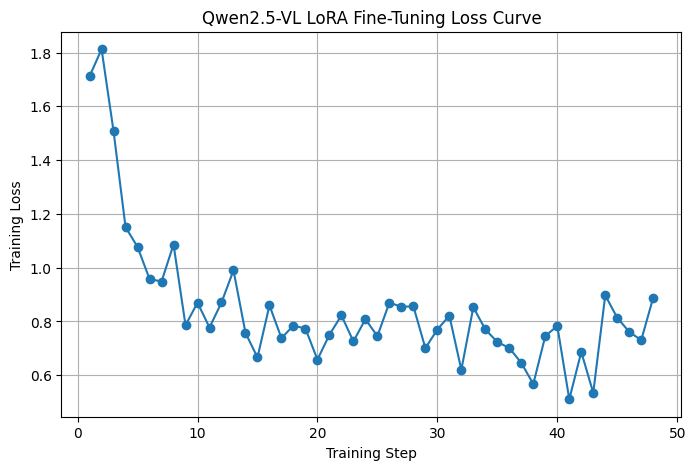

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df_loss["step"], df_loss["loss"], marker="o")
plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("Qwen2.5-VL LoRA Fine-Tuning Loss Curve")
plt.grid(True)
plt.show()

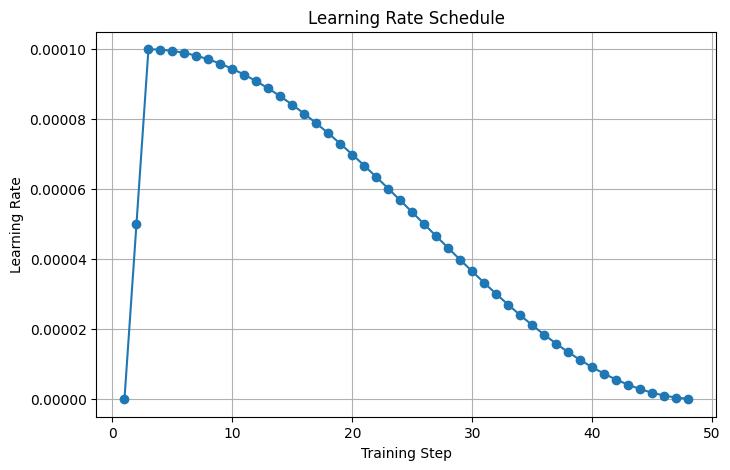

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(df_loss["step"], df_loss["learning_rate"], marker="o")
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.grid(True)
plt.show()

In [ ]:
df_eval_10 = evaluate_resume(
    test_data[:10],
    output_csv="/content/eval_10_promptfix.csv",
    threshold=0.55,
    save_every=5
)

[1/10] Processing -> 3716522.jpg
[2/10] Processing -> 2114070.jpg
[3/10] Processing -> 2366722.jpg
[4/10] Processing -> 2063100.jpg
[5/10] Processing -> 1722404.jpg
Saved 5 rows
[6/10] Processing -> 790777.jpg
[7/10] Processing -> 2544128.jpg
[8/10] Processing -> 2138090.jpg
[9/10] Processing -> 218092.jpg
[10/10] Processing -> 2001998.jpg
Saved 10 rows


In [ ]:
metric_cols = [
    "json_parse_ok",
    "exact_match",
    "is_food_acc",
    "title_similarity",
    "food_precision",
    "food_recall",
    "food_f1",
    "drink_precision",
    "drink_recall",
    "drink_f1",
    "overall_item_f1"
]

scores = df_eval_10[metric_cols].mean()

for k, v in scores.items():
    print(f"{k}: {v:.3f}")

json_parse_ok: 1.000
exact_match: 0.000
is_food_acc: 1.000
title_similarity: 0.550
food_precision: 0.678
food_recall: 0.436
food_f1: 0.517
drink_precision: 0.900
drink_recall: 0.900
drink_f1: 0.900
overall_item_f1: 0.505


In [ ]:
df_eval_20 = evaluate_resume(
    test_data[:20],
    output_csv="/content/eval_20.csv",
    threshold=0.45,
    save_every=10
)

[1/20] Processing -> 3716522.jpg
[2/20] Processing -> 2114070.jpg
[3/20] Processing -> 2366722.jpg
[4/20] Processing -> 2063100.jpg
[5/20] Processing -> 1722404.jpg
[6/20] Processing -> 790777.jpg
[7/20] Processing -> 2544128.jpg
[8/20] Processing -> 2138090.jpg
[9/20] Processing -> 218092.jpg
[10/20] Processing -> 2001998.jpg
Saved 10 rows
[11/20] Processing -> 235744.jpg
[12/20] Processing -> 2121537.jpg
[13/20] Processing -> 1889034.jpg
[14/20] Processing -> 515375.jpg
[15/20] Processing -> 3433423.jpg
[16/20] Processing -> 2185317.jpg
[17/20] Processing -> 517646.jpg
[18/20] Processing -> 2946891.jpg
[19/20] Processing -> 1550392.jpg
[20/20] Processing -> 2834703.jpg
Saved 20 rows


In [ ]:
metric_cols = [
    "json_parse_ok",
    "exact_match",
    "is_food_acc",
    "title_similarity",
    "food_precision",
    "food_recall",
    "food_f1",
    "drink_precision",
    "drink_recall",
    "drink_f1",
    "overall_item_f1"
]

scores = df_eval_10[metric_cols].mean()

for k, v in scores.items():
    print(f"{k}: {v:.3f}")

json_parse_ok: 1.000
exact_match: 0.000
is_food_acc: 1.000
title_similarity: 0.550
food_precision: 0.678
food_recall: 0.436
food_f1: 0.517
drink_precision: 0.900
drink_recall: 0.900
drink_f1: 0.900
overall_item_f1: 0.505


In [ ]:
import json
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

def show_prediction_example(df_eval, idx=0):
    row = df_eval.iloc[idx]

    image_path = IMAGE_DIR / row["image"]
    image = Image.open(image_path).convert("RGB")

    pred = row["pred_text"]
    true = row["true_text"]

    try:
        pred = json.dumps(json.loads(pred), indent=2, ensure_ascii=False)
    except:
        pass

    try:
        true = json.dumps(json.loads(true), indent=2, ensure_ascii=False)
    except:
        pass

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Image: {row['image']} | Overall F1: {row['overall_item_f1']:.3f}")
    plt.show()

    print("PREDICTION JSON:")
    print(pred)

    print("\nGROUND TRUTH JSON:")
    print(true)

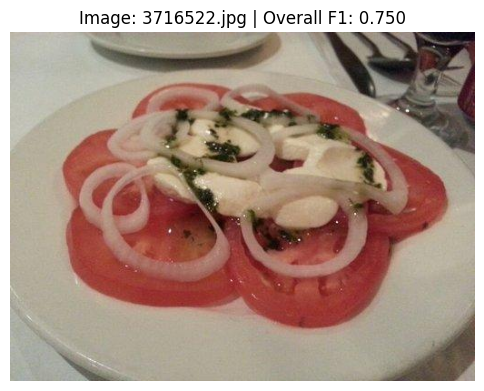

PREDICTION JSON:
{
  "is_food": 1,
  "image_title": "tomato salad",
  "food_items": [
    "onion rings (sliced)",
    "mozzarella cheese chunks",
    "herb dressing"
  ],
  "drink_items": []
}

GROUND TRUTH JSON:
{
  "is_food": 1,
  "image_title": "caprese salad",
  "food_items": [
    "onion ring",
    "tomato slice",
    "basil leaf",
    "mozzarella cheese ball",
    "olive oil dressing"
  ],
  "drink_items": []
}


In [ ]:
show_prediction_example(df_eval_50, idx=0)

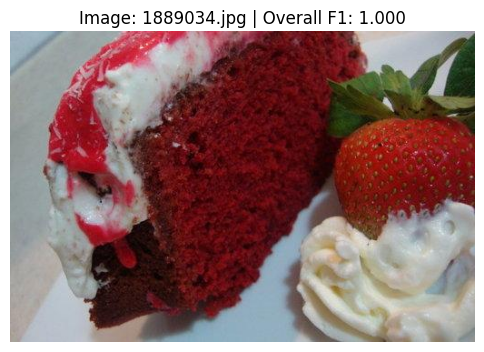

PREDICTION JSON:
{
  "is_food": 1,
  "image_title": "red velvet cake",
  "food_items": [
    "cake slice (red velvet)",
    "whipped cream topping",
    "strawberry"
  ],
  "drink_items": []
}

GROUND TRUTH JSON:
{
  "is_food": 1,
  "image_title": "red velvet cake",
  "food_items": [
    "red velvet cake slice",
    "strawberry",
    "whipped cream"
  ],
  "drink_items": []
}


In [ ]:
best_idx = df_eval_50["overall_item_f1"].idxmax()
show_prediction_example(df_eval_50, idx=best_idx)

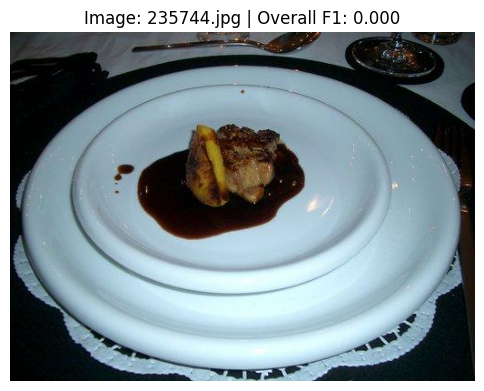

PREDICTION JSON:
{
  "is_food": 1,
  "image_title": "chicken breast",
  "food_items": [
    "apple slice",
    "balsamic reduction"
  ],
  "drink_items": []
}

GROUND TRUTH JSON:
{
  "is_food": 1,
  "image_title": "seared meat dish",
  "food_items": [
    "potato (or root vegetable) wedge",
    "sauce (dark reduction, possibly red wine or balsamic)",
    "seared meat (likely duck or beef)"
  ],
  "drink_items": []
}


In [ ]:
worst_idx = df_eval_50["overall_item_f1"].idxmin()
show_prediction_example(df_eval_50, idx=worst_idx)

In [ ]:
import json
import matplotlib.pyplot as plt
from PIL import Image

def show_multiple_examples(df_eval, n=10, sort_by="overall_item_f1", ascending=False):

    df_show = df_eval.sort_values(sort_by, ascending=ascending).head(n)

    for _, row in df_show.iterrows():

        image_path = IMAGE_DIR / row["image"]
        image = Image.open(image_path).convert("RGB")

        plt.figure(figsize=(5,5))
        plt.imshow(image)
        plt.axis("off")

        plt.title(
            f"{row['image']}\nOverall F1: {row['overall_item_f1']:.3f}"
        )

        plt.show()

        print("="*80)

        print("PREDICTION:")
        try:
            pred = json.dumps(
                json.loads(row["pred_text"]),
                indent=2,
                ensure_ascii=False
            )
            print(pred)
        except:
            print(row["pred_text"])

        print("\nGROUND TRUTH:")
        try:
            gt = json.dumps(
                json.loads(row["true_text"]),
                indent=2,
                ensure_ascii=False
            )
            print(gt)
        except:
            print(row["true_text"])

        print("="*80)
        print("\n")

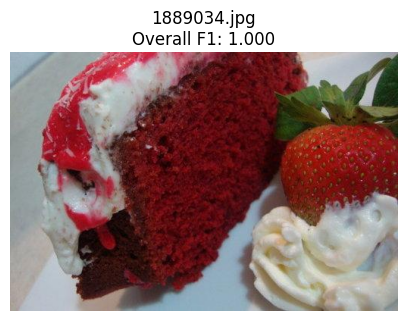

PREDICTION:
{
  "is_food": 1,
  "image_title": "red velvet cake",
  "food_items": [
    "cake slice (red velvet)",
    "whipped cream topping",
    "strawberry"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "red velvet cake",
  "food_items": [
    "red velvet cake slice",
    "strawberry",
    "whipped cream"
  ],
  "drink_items": []
}




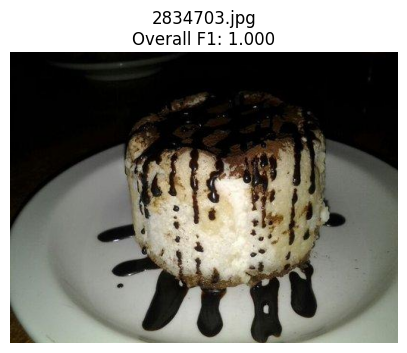

PREDICTION:
{
  "is_food": 1,
  "image_title": "chocolate cake",
  "food_items": [
    "cake base (white)",
    "chocolate drizzle"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "chocolate-drizzled dessert",
  "food_items": [
    "chocolate sauce",
    "cake"
  ],
  "drink_items": []
}




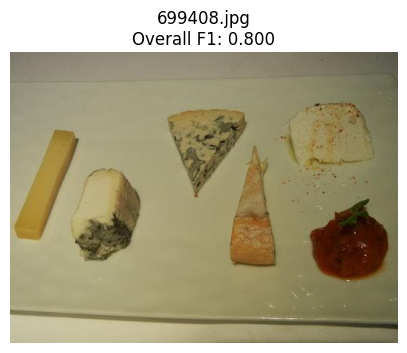

PREDICTION:
{
  "is_food": 1,
  "image_title": "cheese plate",
  "food_items": [
    "blue cheese wedge",
    "cheddar stick",
    "crumbled blue cheese",
    "pimento cheese wedge (with red pepper flakes)",
    "red sauce"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "",
  "food_items": [
    "wedge of aged cheese with rind",
    "dollop of red sauce with herb garnish",
    "blue cheese wedge",
    "blue cheese wedge with rind",
    "cheese stick (yellow)"
  ],
  "drink_items": []
}




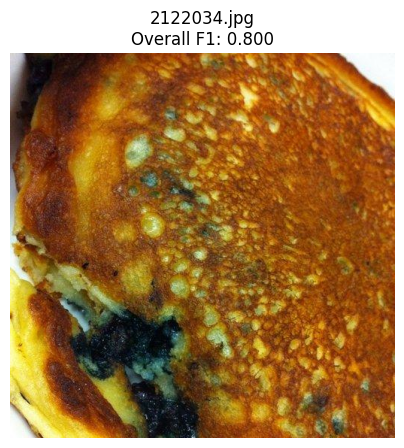

PREDICTION:
{
  "is_food": 1,
  "image_title": "blueberry pancake",
  "food_items": [
    "pancake batter (golden brown)",
    "blueberries",
    "pancake crust"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "pancake",
  "food_items": [
    "blueberry",
    "pancake batter"
  ],
  "drink_items": []
}




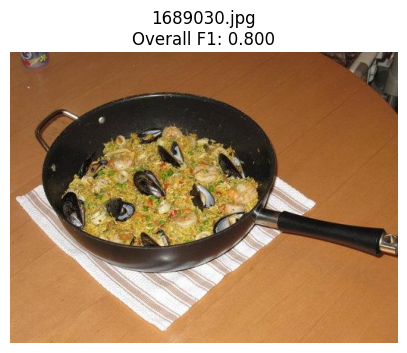

PREDICTION:
{
  "is_food": 1,
  "image_title": "paella",
  "food_items": [
    "mussels (black shells)",
    "rice (yellowish color)",
    "shrimp (white meat, pink tail)",
    "peppers (red and green pieces)"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "seafood paella",
  "food_items": [
    "rice",
    "green peppers",
    "mussels",
    "chopped onions",
    "red peppers",
    "shrimp"
  ],
  "drink_items": []
}




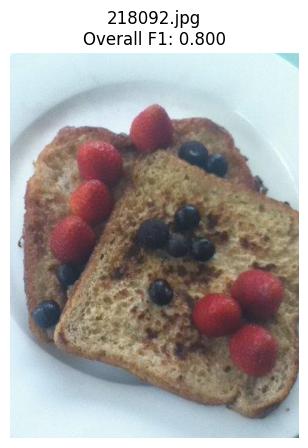

PREDICTION:
{
  "is_food": 1,
  "image_title": "fruit toast",
  "food_items": [
    "blueberry",
    "raspberry"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "French toast",
  "food_items": [
    "blueberry",
    "bread slice",
    "strawberry"
  ],
  "drink_items": []
}




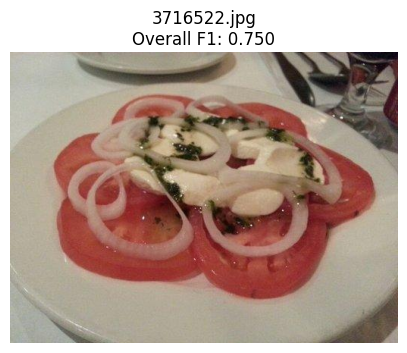

PREDICTION:
{
  "is_food": 1,
  "image_title": "tomato salad",
  "food_items": [
    "onion rings (sliced)",
    "mozzarella cheese chunks",
    "herb dressing"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "caprese salad",
  "food_items": [
    "onion ring",
    "tomato slice",
    "basil leaf",
    "mozzarella cheese ball",
    "olive oil dressing"
  ],
  "drink_items": []
}




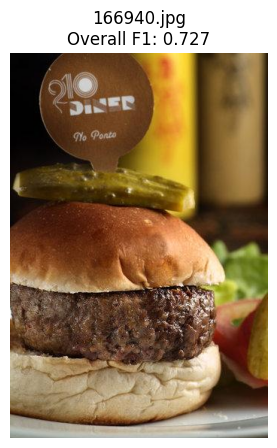

PREDICTION:
{
  "is_food": 1,
  "image_title": "hamburger",
  "food_items": [
    "lettuce",
    "pickle slice",
    "bun (top)",
    "beef patty"
  ],
  "drink_items": [
    "sauce"
  ]
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "hamburger",
  "food_items": [
    "top bun",
    "tomato slice",
    "pickle spear",
    "toothpick with diner logo",
    "beef patty",
    "lettuce leaf"
  ],
  "drink_items": []
}




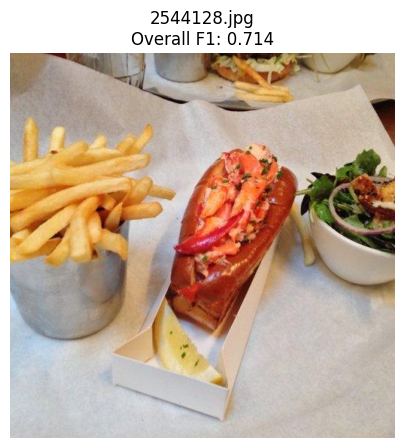

PREDICTION:
{
  "is_food": 1,
  "image_title": "lobster roll",
  "food_items": [
    "lemon wedge",
    "french fries (in cup)",
    "salad greens",
    "onion slice",
    "croutons",
    "lobster meat"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "lobster roll french fries side salad",
  "food_items": [
    "red onion",
    "lobster meat",
    "toasted bun",
    "dressing",
    "mixed greens",
    "crouton",
    "french fry",
    "lemon wedge"
  ],
  "drink_items": []
}




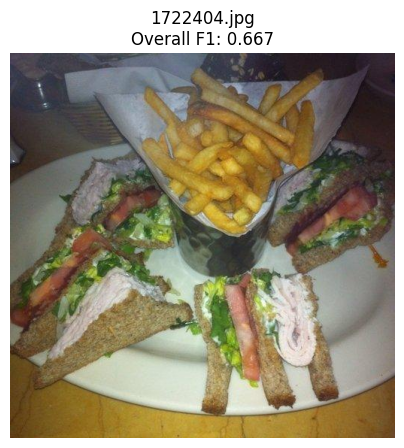

PREDICTION:
{
  "is_food": 1,
  "image_title": "sandwiches french fries",
  "food_items": [
    "bread (wheat bread)",
    "lettuce",
    "tomato slice",
    "turkey meat",
    "cheese slice"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "club sandwich french fries",
  "food_items": [
    "lettuce",
    "turkey slices",
    "bacon strips",
    "french fries",
    "bread (sliced, toasted)",
    "tomato slices",
    "mayonnaise"
  ],
  "drink_items": []
}




In [ ]:
show_multiple_examples(
    df_eval_50,
    n=10,
    sort_by="overall_item_f1",
    ascending=False
)

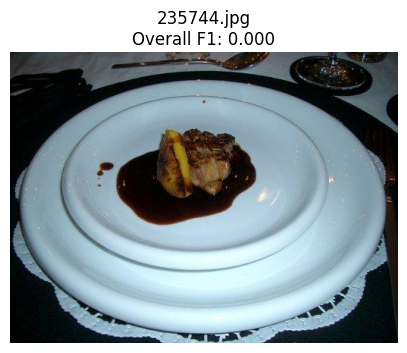

PREDICTION:
{
  "is_food": 1,
  "image_title": "chicken breast",
  "food_items": [
    "apple slice",
    "balsamic reduction"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "seared meat dish",
  "food_items": [
    "potato (or root vegetable) wedge",
    "sauce (dark reduction, possibly red wine or balsamic)",
    "seared meat (likely duck or beef)"
  ],
  "drink_items": []
}




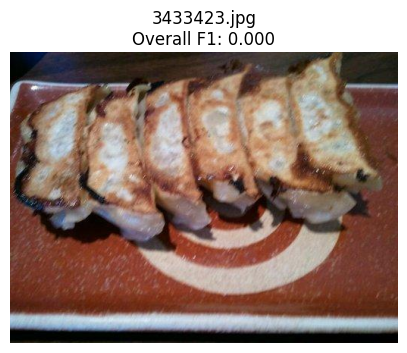

PREDICTION:
{
  "is_food": 1,
  "image_title": "grilled shrimp",
  "food_items": [
    "shrimp"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "gyoza",
  "food_items": [
    "gyoza dumpling"
  ],
  "drink_items": []
}




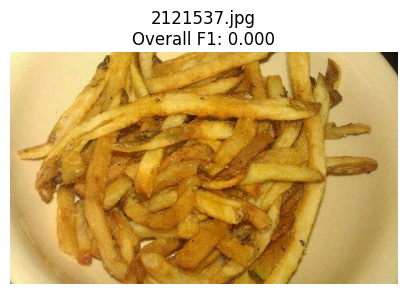

PREDICTION:
{
  "is_food": 1,
  "image_title": "french fries",
  "food_items": [
    "fried potato strip"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "french fries",
  "food_items": [
    "french fry"
  ],
  "drink_items": []
}




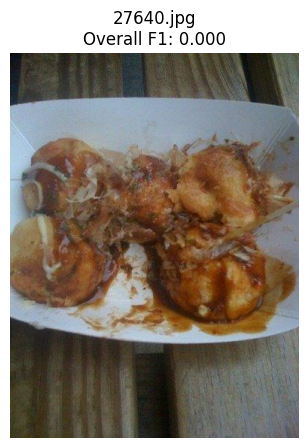

PREDICTION:
{
  "is_food": 1,
  "image_title": "shrimp tempura",
  "food_items": [
    "tempura batter coating"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "takoyaki",
  "food_items": [
    "takoyaki sauce",
    "bonito flakes",
    "mayonnaise",
    "takoyaki ball"
  ],
  "drink_items": []
}




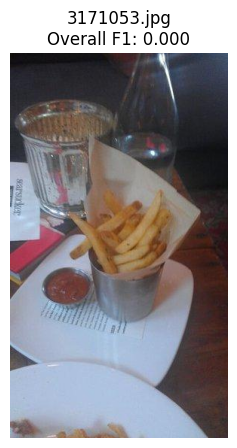

PREDICTION:
{
  "is_food": 1,
  "image_title": "french fries",
  "food_items": [
    "ketchup"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "french fries",
  "food_items": [
    "french fry"
  ],
  "drink_items": [
    "water"
  ]
}




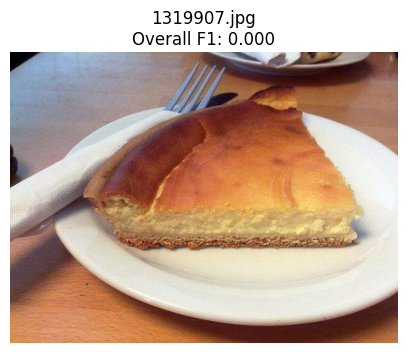

PREDICTION:
{
  "is_food": 1,
  "image_title": "cheesecake",
  "food_items": [
    "cake layer (top)",
    "cake layer"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "cheesecake",
  "food_items": [
    "baked crust",
    "cheesecake filling",
    "graham cracker crust"
  ],
  "drink_items": []
}




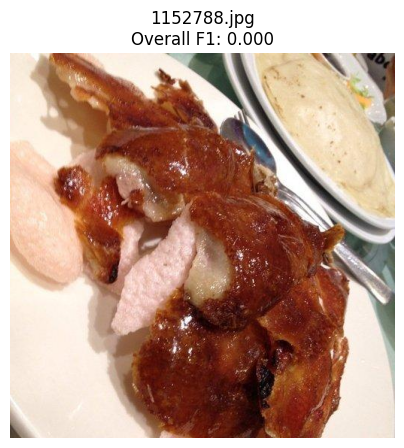

PREDICTION:
{
  "is_food": 1,
  "image_title": "roasted chicken",
  "food_items": [
    "chicken thigh",
    "sauce (glaze)",
    "bread roll"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "roasted duck",
  "food_items": [
    "duck meat",
    "roasted duck breast",
    "duck skin",
    "steamed bun (pinkish)"
  ],
  "drink_items": []
}




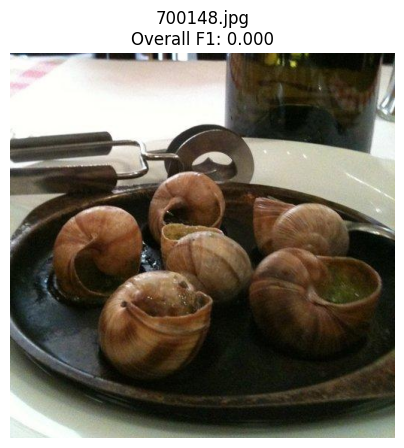

PREDICTION:
{"is_food":1,"image_title":"escargot","food_items":["herb butter sauce (greenish),"snail shell"],"drink_items":["wine bottle"]}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "escargot",
  "food_items": [
    "garlic",
    "butter sauce",
    "snail shell",
    "parsley",
    "snail meat"
  ],
  "drink_items": []
}




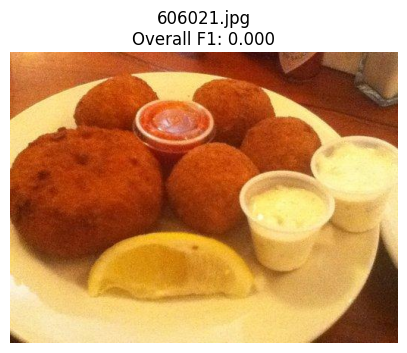

PREDICTION:
{
  "is_food": 1,
  "image_title": "fried hush puppies",
  "food_items": [
    "hush puppy (top left)",
    "hush puppie (bottom center)",
    "hustle dip (left cup)",
    "hussie sauce (right of top cup)",
    "sour cream (right bottom cup)"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "fried croquettes",
  "food_items": [
    "tartar sauce",
    "lemon wedge",
    "ketchup",
    "fried croquette"
  ],
  "drink_items": []
}




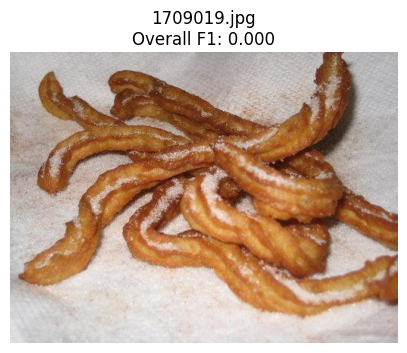

PREDICTION:
{
  "is_food": 1,
  "image_title": "churros",
  "food_items": [
    "sugar coating"
  ],
  "drink_items": []
}

GROUND TRUTH:
{
  "is_food": 1,
  "image_title": "churros",
  "food_items": [
    "churro"
  ],
  "drink_items": []
}




In [ ]:
show_multiple_examples(
    df_eval_50,
    n=10,
    sort_by="overall_item_f1",
    ascending=True
)

In [ ]:
import json
import matplotlib.pyplot as plt
from PIL import Image

def show_multiple_examples(df_eval, n=10, sort_by="overall_item_f1", ascending=False):

    df_show = df_eval.sort_values(sort_by, ascending=ascending).head(n)

    for _, row in df_show.iterrows():

        image_path = IMAGE_DIR / row["image"]
        image = Image.open(image_path).convert("RGB")

        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.axis("off")

        plt.title(
            f"{row['image']}\n"
            f"OverallF1={row['overall_item_f1']:.3f} | "
            f"FoodF1={row['food_f1']:.3f}"
        )

        plt.show()

        print("=" * 100)

        print("METRICS:")
        print(f"JSON Parse OK   : {row['json_parse_ok']}")
        print(f"Exact Match     : {row['exact_match']}")
        print(f"is_food Acc     : {row['is_food_acc']}")
        print(f"Title Similarity: {row['title_similarity']:.3f}")
        print(f"Food Precision  : {row['food_precision']:.3f}")
        print(f"Food Recall     : {row['food_recall']:.3f}")
        print(f"Food F1         : {row['food_f1']:.3f}")

        try:
            pred_json = json.loads(row["pred_text"])
        except:
            pred_json = {}

        try:
            true_json = json.loads(row["true_text"])
        except:
            true_json = {}

        pred_drinks = pred_json.get("drink_items", [])
        true_drinks = true_json.get("drink_items", [])

        if len(pred_drinks) > 0 or len(true_drinks) > 0:
            print(f"Drink Precision : {row['drink_precision']:.3f}")
            print(f"Drink Recall    : {row['drink_recall']:.3f}")
            print(f"Drink F1        : {row['drink_f1']:.3f}")

        print(f"Overall Item F1 : {row['overall_item_f1']:.3f}")

        print("\nPREDICTION:")
        try:
            pred = json.dumps(
                json.loads(row["pred_text"]),
                indent=2,
                ensure_ascii=False
            )
            print(pred)
        except:
            print(row["pred_text"])

        print("\nGROUND TRUTH:")
        try:
            gt = json.dumps(
                json.loads(row["true_text"]),
                indent=2,
                ensure_ascii=False
            )
            print(gt)
        except:
            print(row["true_text"])

        print("=" * 100)
        print("\n")

In [ ]:
show_multiple_examples(df_eval_50, n=10, sort_by="overall_item_f1", ascending=False)

In [ ]:
show_multiple_examples(df_eval_50, n=10, sort_by="overall_item_f1", ascending=True)

In [ ]:
import json
import textwrap
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

SAVE_DIR = Path("/content/example_outputs")
SAVE_DIR.mkdir(exist_ok=True)

def save_example_outputs(df_eval, n=10, sort_by="overall_item_f1", ascending=False):

    df_show = df_eval.sort_values(sort_by, ascending=ascending).head(n)

    for i, (_, row) in enumerate(df_show.iterrows()):

        image_path = IMAGE_DIR / row["image"]
        image = Image.open(image_path).convert("RGB")

        try:
            pred_json = json.loads(row["pred_text"])
            pred_text = json.dumps(pred_json, indent=2, ensure_ascii=False)
        except:
            pred_text = row["pred_text"]

        try:
            true_json = json.loads(row["true_text"])
            true_text = json.dumps(true_json, indent=2, ensure_ascii=False)
        except:
            true_text = row["true_text"]

        metrics_text = f"""
JSON Parse OK   : {row['json_parse_ok']}
Exact Match     : {row['exact_match']}
is_food Acc     : {row['is_food_acc']}
Title Similarity: {row['title_similarity']:.3f}
Food Precision  : {row['food_precision']:.3f}
Food Recall     : {row['food_recall']:.3f}
Food F1         : {row['food_f1']:.3f}
Overall Item F1 : {row['overall_item_f1']:.3f}
"""

        wrapped_pred = "\n".join(textwrap.wrap(pred_text, width=80))
        wrapped_true = "\n".join(textwrap.wrap(true_text, width=80))

        fig = plt.figure(figsize=(12, 10))

        ax1 = fig.add_subplot(2,1,1)
        ax1.imshow(image)
        ax1.axis("off")

        ax1.set_title(
            f"{row['image']} | Overall F1={row['overall_item_f1']:.3f}"
        )

        ax2 = fig.add_subplot(2,1,2)
        ax2.axis("off")

        text = (
            "METRICS\n"
            + metrics_text
            + "\nPREDICTION\n"
            + wrapped_pred
            + "\n\nGROUND TRUTH\n"
            + wrapped_true
        )

        ax2.text(
            0,
            1,
            text,
            fontsize=9,
            va="top",
            family="monospace"
        )

        out_path = SAVE_DIR / f"example_{i}.png"

        plt.tight_layout()
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.close()

        print(f"Saved -> {out_path}")

In [ ]:
save_example_outputs(
    df_eval_50,
    n=10,
    sort_by="overall_item_f1",
    ascending=False
)

Saved -> /content/example_outputs/example_0.png
Saved -> /content/example_outputs/example_1.png
Saved -> /content/example_outputs/example_2.png
Saved -> /content/example_outputs/example_3.png
Saved -> /content/example_outputs/example_4.png
Saved -> /content/example_outputs/example_5.png
Saved -> /content/example_outputs/example_6.png
Saved -> /content/example_outputs/example_7.png
Saved -> /content/example_outputs/example_8.png
Saved -> /content/example_outputs/example_9.png


In [ ]:
save_example_outputs(
    df_eval_50,
    n=10,
    sort_by="overall_item_f1",
    ascending=True
)

Saved -> /content/example_outputs/example_0.png
Saved -> /content/example_outputs/example_1.png
Saved -> /content/example_outputs/example_2.png
Saved -> /content/example_outputs/example_3.png
Saved -> /content/example_outputs/example_4.png
Saved -> /content/example_outputs/example_5.png
Saved -> /content/example_outputs/example_6.png
Saved -> /content/example_outputs/example_7.png
Saved -> /content/example_outputs/example_8.png
Saved -> /content/example_outputs/example_9.png


In [ ]:
!zip -r /content/example_outputs.zip /content/example_outputs

  adding: content/example_outputs/ (stored 0%)
  adding: content/example_outputs/example_4.png (deflated 6%)
  adding: content/example_outputs/example_9.png (deflated 2%)
  adding: content/example_outputs/example_3.png (deflated 4%)
  adding: content/example_outputs/example_6.png (deflated 3%)
  adding: content/example_outputs/example_7.png (deflated 4%)
  adding: content/example_outputs/example_2.png (deflated 8%)
  adding: content/example_outputs/example_0.png (deflated 3%)
  adding: content/example_outputs/example_5.png (deflated 3%)
  adding: content/example_outputs/example_1.png (deflated 2%)
  adding: content/example_outputs/example_8.png (deflated 3%)


In [ ]:
from google.colab import files
files.download("/content/example_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=561f42edb910a932efbc5471d9ee3bd97b284c211d8beba11c84533a9de26c96
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [ ]:

from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)

def compute_rouge(pred_text, true_text):

    scores = scorer.score(true_text, pred_text)

    return {
        "rouge1_f": scores["rouge1"].fmeasure,
        "rouge2_f": scores["rouge2"].fmeasure,
        "rougeL_f": scores["rougeL"].fmeasure,
    }

In [ ]:
def evaluate_one(sample, idx, threshold=0.45):

    pred_text = run_inference_safe(sample)

    pred_json = extract_json(pred_text)

    true_json = json.loads(sample["conversations"][1]["value"])

    # JSON parse başarısızsa
    if pred_json is None:

        return {
            "idx": idx,
            "image": sample["image"],
            "json_parse_ok": 0,
            "exact_match": 0,
            "is_food_acc": 0,
            "title_similarity": 0,
            "food_precision": 0,
            "food_recall": 0,
            "food_f1": 0,
            "drink_precision": 0,
            "drink_recall": 0,
            "drink_f1": 0,
            "overall_item_f1": 0,
            "rouge1_f": 0,
            "rougeL_f": 0,
            "rouge1_f": 0,
            "rouge2_f": 0,
            "rougeL_f": 0,
            "pred_text": pred_text,
            "true_text": sample["conversations"][1]["value"],
        }

    # FOOD METRICS
    food_p, food_r, food_f1 = fuzzy_prf1(
        pred_json.get("food_items", []),
        true_json.get("food_items", []),
        threshold=threshold
    )

    # DRINK METRICS
    drink_p, drink_r, drink_f1 = fuzzy_prf1(
        pred_json.get("drink_items", []),
        true_json.get("drink_items", []),
        threshold=threshold
    )

    # OVERALL ITEM F1
    pred_all = (
        pred_json.get("food_items", [])
        + pred_json.get("drink_items", [])
    )

    true_all = (
        true_json.get("food_items", [])
        + true_json.get("drink_items", [])
    )

    _, _, overall_f1 = fuzzy_prf1(
        pred_all,
        true_all,
        threshold=threshold
    )

    # ROUGE
    rouge_scores = compute_rouge(
        json.dumps(pred_json, ensure_ascii=False),
        json.dumps(true_json, ensure_ascii=False)
    )

    return {

        "idx": idx,
        "image": sample["image"],

        "json_parse_ok": 1,

        "exact_match": int(pred_json == true_json),

        "is_food_acc": int(
            pred_json.get("is_food")
            == true_json.get("is_food")
        ),

        "title_similarity": similarity(
            pred_json.get("image_title", ""),
            true_json.get("image_title", "")
        ),

        "food_precision": food_p,
        "food_recall": food_r,
        "food_f1": food_f1,

        "drink_precision": drink_p,
        "drink_recall": drink_r,
        "drink_f1": drink_f1,

        "overall_item_f1": overall_f1,

        "rouge1_f": rouge_scores["rouge1_f"],
        "rouge2_f": rouge_scores["rouge2_f"],
        "rougeL_f": rouge_scores["rougeL_f"],

        "pred_text": json.dumps(
            pred_json,
            ensure_ascii=False
        ),

        "true_text": sample["conversations"][1]["value"],
    }

In [ ]:
df_eval_50.columns

Index(['idx', 'image', 'json_parse_ok', 'exact_match', 'is_food_acc',
       'title_similarity', 'food_precision', 'food_recall', 'food_f1',
       'drink_precision', 'drink_recall', 'drink_f1', 'overall_item_f1',
       'pred_text', 'true_text'],
      dtype='str')

In [ ]:
!rm -f /content/eval_50_rouge.csv

In [ ]:
df_eval_50_rouge = evaluate_resume(
    test_data[:50],
    output_csv="/content/eval_50_rouge.csv",
    threshold=0.55,
    save_every=10
)

[1/50] Processing -> 3716522.jpg
[2/50] Processing -> 2114070.jpg
[3/50] Processing -> 2366722.jpg
[4/50] Processing -> 2063100.jpg
[5/50] Processing -> 1722404.jpg
[6/50] Processing -> 790777.jpg
[7/50] Processing -> 2544128.jpg
[8/50] Processing -> 2138090.jpg
[9/50] Processing -> 218092.jpg
[10/50] Processing -> 2001998.jpg
Saved 10 rows
[11/50] Processing -> 235744.jpg
[12/50] Processing -> 2121537.jpg
[13/50] Processing -> 1889034.jpg
[14/50] Processing -> 515375.jpg
[15/50] Processing -> 3433423.jpg
[16/50] Processing -> 2185317.jpg
[17/50] Processing -> 517646.jpg
[18/50] Processing -> 2946891.jpg
[19/50] Processing -> 1550392.jpg
[20/50] Processing -> 2834703.jpg
Saved 20 rows
[21/50] Processing -> 1152788.jpg
[22/50] Processing -> 151726.jpg
[23/50] Processing -> 700148.jpg
[24/50] Processing -> 2324732.jpg
[25/50] Processing -> 3171053.jpg
[26/50] Processing -> 913716.jpg
[27/50] Processing -> 60474.jpg
[28/50] Processing -> 1319907.jpg
[29/50] Processing -> 1689030.jpg
[30/5

In [ ]:
df_eval_50_rouge[["rouge1_f", "rougeL_f"]].mean()

rouge1_f    0.657095
rougeL_f    0.602633
dtype: float64

In [ ]:
metric_cols = [
    "json_parse_ok",
    "exact_match",
    "is_food_acc",
    "title_similarity",
    "food_precision",
    "food_recall",
    "food_f1",
    "drink_precision",
    "drink_recall",
    "drink_f1",
    "overall_item_f1",
    "rouge1_f",
    "rougeL_f"
]

scores = df_eval_50_rouge[metric_cols].mean()

for k, v in scores.items():
    print(f"{k}: {v:.3f}")

json_parse_ok: 0.980
exact_match: 0.000
is_food_acc: 0.980
title_similarity: 0.578
food_precision: 0.501
food_recall: 0.376
food_f1: 0.421
drink_precision: 0.900
drink_recall: 0.910
drink_f1: 0.893
overall_item_f1: 0.430
rouge1_f: 0.657
rougeL_f: 0.603


In [ ]:
df_eval_10_rouge = evaluate_resume(
    test_data[:10],
    output_csv="/content/eval_10_rouge.csv",
    threshold=0.55,
    save_every=5
)

[1/10] Processing -> 3716522.jpg
[2/10] Processing -> 2114070.jpg
[3/10] Processing -> 2366722.jpg
[4/10] Processing -> 2063100.jpg
[5/10] Processing -> 1722404.jpg
Saved 5 rows
[6/10] Processing -> 790777.jpg
[7/10] Processing -> 2544128.jpg
[8/10] Processing -> 2138090.jpg
[9/10] Processing -> 218092.jpg
[10/10] Processing -> 2001998.jpg
Saved 10 rows


In [ ]:
metric_cols = [
    "json_parse_ok",
    "exact_match",
    "is_food_acc",
    "title_similarity",
    "food_precision",
    "food_recall",
    "food_f1",
    "drink_precision",
    "drink_recall",
    "drink_f1",
    "overall_item_f1",
    "rouge1_f",
    "rouge2_f",
    "rougeL_f"
]

scores = df_eval_10_rouge[metric_cols].mean()

for k, v in scores.items():
    print(f"{k}: {v:.3f}")

json_parse_ok: 1.000
exact_match: 0.000
is_food_acc: 1.000
title_similarity: 0.606
food_precision: 0.730
food_recall: 0.492
food_f1: 0.582
drink_precision: 0.900
drink_recall: 0.900
drink_f1: 0.900
overall_item_f1: 0.565
rouge1_f: 0.703
rouge2_f: 0.445
rougeL_f: 0.631
